In [330]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
import plotly

In [331]:
# Leemos el Data Frame
df = pd.read_csv("afluencia_rtp_cdmx.csv", encoding='latin-1')

# Cambiamos manualmente los caracteres "raros"
# Corrección directa de los nombres afectados
df['servicio'] = df['servicio'].replace({
    'EcobÃºs': 'Ecobús',
    'NochebÃºs': 'Nochebús'
})

In [332]:
# Vemos si hay datos nulos
df.isna().sum()

fecha         24
mes           24
anio          24
servicio      24
tipo_pago      0
afluencia    211
dtype: int64

In [333]:
# Vemos las dimensiones del set de datos
df.shape

(38589, 6)

In [334]:
# Vemos el tipo de dato de cada columna
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38589 entries, 0 to 38588
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   fecha      38565 non-null  str    
 1   mes        38565 non-null  str    
 2   anio       38565 non-null  float64
 3   servicio   38565 non-null  str    
 4   tipo_pago  38589 non-null  str    
 5   afluencia  38378 non-null  float64
dtypes: float64(2), str(4)
memory usage: 1.8 MB


In [335]:
df["anio"].value_counts()

anio
2022.0    9855
2024.0    9072
2023.0    8994
2025.0    8253
2026.0    2391
Name: count, dtype: int64

In [336]:
df.head(20)

,fecha,mes,anio,servicio,tipo_pago,afluencia
0,2022-01-01,Enero,2022.0,Servicios Temporales,Boleto,0.0
1,2022-01-01,Enero,2022.0,Servicios Temporales,Prepago,0.0
2,2022-01-01,Enero,2022.0,Servicios Temporales,Gratuidad,0.0
3,2022-01-01,Enero,2022.0,Atenea,Boleto,2702.0
4,2022-01-01,Enero,2022.0,Atenea,Prepago,0.0
5,2022-01-01,Enero,2022.0,Atenea,Gratuidad,467.0
6,2022-01-01,Enero,2022.0,Ecoatenea,Boleto,0.0
7,2022-01-01,Enero,2022.0,Ecoatenea,Prepago,0.0
8,2022-01-01,Enero,2022.0,Ecoatenea,Gratuidad,0.0
9,2022-01-01,Enero,2022.0,Ecobús,Boleto,5652.0


## Todos los servicios del RTP (de la columna _"servicio"_)


In [337]:
# Pasamos todo a MAYÚSCULAS y quitamos espacios a los lados
df['servicio'] = df['servicio'].astype(str).str.upper().str.strip()

# Diccionario maestro usando patrones Regex para los casos rebeldes
mapeo_regex = {
    r'.*NOCHEB.*': 'NOCHEBÚS',  # Cualquier texto que contenga "NOCHEB" se vuelve "NOCHEBÚS"
    r'.*ECOB.*': 'ECOBÚS',      # Cualquier texto que contenga "ECOB" se vuelve "ECOBÚS"
    'EXPRESO DIRECTO': 'EXPDIRECTO',
    'APOYO METRO L1': 'SERVICIOS TEMPORALES',
    'APOYO CONCESIONADO': 'APOYO CONCESIONADO',
    'APOYO A CONCESIONADO': 'APOYO CONCESIONADO',
    r'.*CIRCUITO.*': 'CIRCUITO HOSPITALES',  # Cualquier texto que contenga "CIRCUITO" se vuelve "CIRCUITO HOSPITALES"
    'S/METRO': 'SUSTITUTO DE METRO'
}

df['servicio'] = df['servicio'].replace(mapeo_regex, regex=True)

print("--- Conteo de filas por servicio (Totalmente Limpio) ---")
print(df['servicio'].value_counts())

--- Conteo de filas por servicio (Totalmente Limpio) ---
servicio
ATENEA                  5019
ECOBÚS                  4833
NOCHEBÚS                4806
EXPRESO                 4743
ORDINARIO               4743
EXPDIRECTO              4383
SUSTITUTO DE METRO      4269
SERVICIOS TEMPORALES    3351
ECOATENEA               1179
CIRCUITO HOSPITALES      975
APOYO CONCESIONADO       264
Name: count, dtype: int64


In [338]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38589 entries, 0 to 38588
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   fecha      38565 non-null  str    
 1   mes        38565 non-null  str    
 2   anio       38565 non-null  float64
 3   servicio   38565 non-null  str    
 4   tipo_pago  38589 non-null  str    
 5   afluencia  38378 non-null  float64
dtypes: float64(2), str(4)
memory usage: 1.8 MB


In [339]:
df["anio"].value_counts()

anio
2022.0    9855
2024.0    9072
2023.0    8994
2025.0    8253
2026.0    2391
Name: count, dtype: int64

/var/folders/8k/r7mpdwj10lq28v41d5cp4mjr0000gn/T/ipykernel_1186/980638748.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barras = sns.barplot(x=afluencia_por_servicio.index,


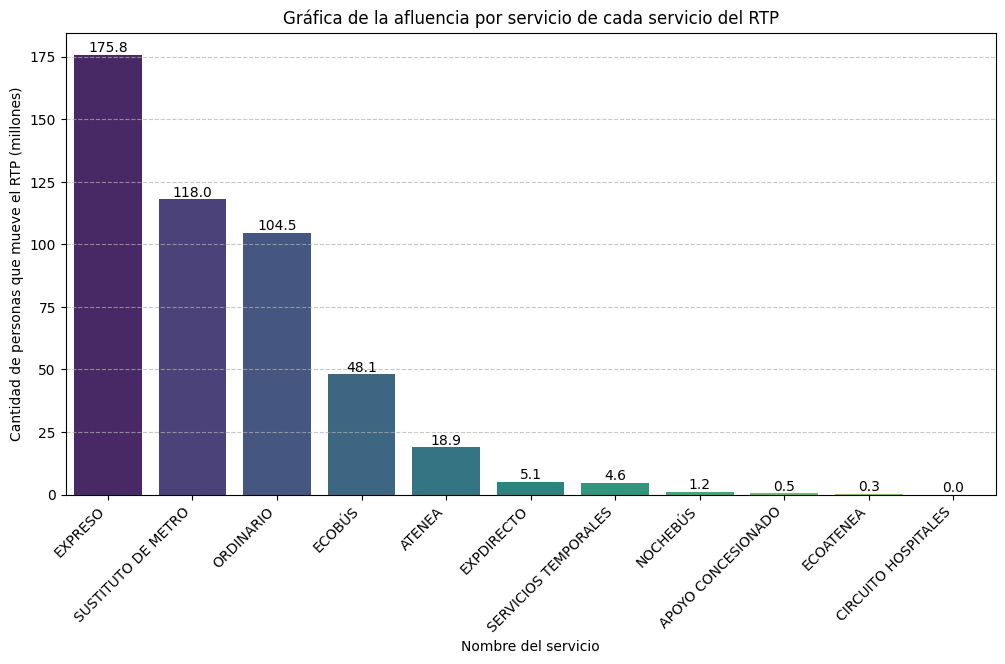

In [340]:
# ----- Agrupación y gráfica de la afluencia por servicio de cada servicio del RTP -----

# Afluencia por servicio
afluencia_por_servicio = df.groupby("servicio")["afluencia"].sum().sort_values(ascending=False).round(2)

# Graficamos
plt.figure(figsize=(12,6))
plt.title("Gráfica de la afluencia por servicio de cada servicio del RTP")
barras = sns.barplot(x=afluencia_por_servicio.index,
                     y=afluencia_por_servicio.values / 1_000_000,
                     palette="viridis")
for contenedores in barras.containers:
    barras.bar_label(contenedores,
                     fmt='%.1f')
plt.xlabel("Nombre del servicio")
plt.ylabel("Cantidad de personas que mueve el RTP (millones)")
plt.xticks(rotation=45,
           ha="right")
plt.grid(axis="y",
         linestyle="--",
         alpha=0.7)
plt.show()

/var/folders/8k/r7mpdwj10lq28v41d5cp4mjr0000gn/T/ipykernel_1186/3578644557.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  barras = sns.barplot(x=afluencia_por_año.index,


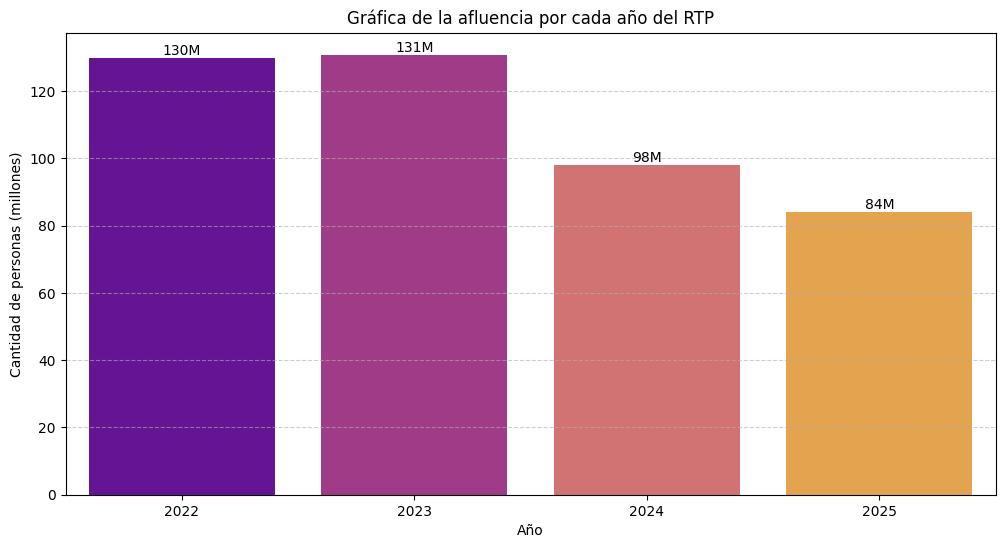

In [346]:
# ----- Agrupación y gráfica de la afluencia por año de cada servicio del RTP -----

# Creamos un nuevo Data Frame sin el año 2026, ya que el 2026 aún no ha acabado
df_sin_2026 = df[df["anio"] != 2026].copy()

# Convertimos la columa "anio" del Data Frame sin el 2026
df_sin_2026["anio"] = df_sin_2026["anio"].astype('Int64')

# Afluencia por año
afluencia_por_año = df_sin_2026.groupby("anio")["afluencia"].sum()

# Graficamos
plt.figure(figsize=(12,6))
plt.title("Gráfica de la afluencia por cada año del RTP")
barras = sns.barplot(x=afluencia_por_año.index,
                     y=afluencia_por_año.values / 1_000_000,
                     palette="plasma")
for contenedores in barras.containers:
    barras.bar_label(contenedores,
                     fmt='%.0fM')
plt.xlabel("Año")
plt.ylabel("Cantidad de personas (millones)")
plt.grid(axis="y",
         linestyle="--",
         alpha=0.6)
plt.show()